In [1]:
!pip install scikit-misc

In [2]:
import glob
import time

import h5py
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric._smoothers_lowess import lowess as _sm_lowess
from statsmodels.robust.norms import TukeyBiweight

from aind_ophys_utils.signal_utils import percentile_filter

In [3]:
from dev import single_exp, double_exp, bright, nonlinear_fit, AsymmetricTukeyBiweight, AsymmetricTukeyBiweight_jax

In [4]:
%matplotlib inline

## Function definitions

In [5]:
def fit_baseline_fluctuations_sm(
    trace: np.ndarray,
    t: np.ndarray,
    trend: np.ndarray | None = None,
    frac: float = 0.1,
    weights: np.ndarray | None = None,
    mode: str = "ratio",
) -> tuple[np.ndarray, np.ndarray]:
    """Baseline fluctuation fit using statsmodels._smoothers_lowess (resid_weights)."""
    if trend is None:
        y = trace
    elif mode == "ratio":
        y = trace / np.where(trend != 0, trend, np.nan)
    else:
        y = trace - trend

    w = np.asarray(weights, dtype=np.float64) if weights is not None else np.ones(len(y))

    # t must be float64 and sorted; resid_weights multiplies into local WLS kernel
    fluctuation = _sm_lowess(
        y.astype(np.float64),
        t.astype(np.float64),
        t.astype(np.float64),
        resid_weights=w,
        frac=frac,
        it=0,               # no internal robustness iterations — weights handle it
        delta=0.01 * (t[-1] - t[0]),
    )[0][:,1]
    if trend is None:
        return fluctuation, fluctuation
    baseline = trend * fluctuation if mode == "ratio" else trend + fluctuation
    return baseline, fluctuation


def fit_baseline_fluctuations_skmisc(
    trace: np.ndarray,
    t: np.ndarray,
    trend: np.ndarray | None = None,
    frac: float = 0.1,
    weights: np.ndarray | None = None,
    degree: int = 1,
    mode: str = "ratio",
) -> tuple[np.ndarray, np.ndarray]:
    """Baseline fluctuation fit using skmisc.loess."""
    from skmisc.loess import loess

    if trend is None:
        y = trace
    elif mode == "ratio":
        y = trace / np.where(trend != 0, trend, np.nan)
    else:
        y = trace - trend

    w = np.asarray(weights, dtype=np.float64) if weights is not None else None

    lo = loess(
        t.astype(np.float64),
        y.astype(np.float64),
        weights=w,
        span=frac,
        degree=degree,
    )
    lo.fit()
    fluctuation = lo.outputs.fitted_values
    if trend is None:
        return fluctuation, fluctuation

    baseline = trend * fluctuation if mode == "ratio" else trend + fluctuation
    return baseline, fluctuation

#### load data 

In [6]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

## Data 

In [7]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [8]:
traces = get_valid_corrected_f(dirs[0])

In [9]:
trace = traces[0][0]

In [10]:
frame_rate = 10.63  # looked up manually from session.json of multiplane-ophys_804670_2025-09-24_09-30-56_processed_2025-10-10_22-28-44
timestamps = np.arange(len(trace)) / frame_rate

## fit baseline fluctuations

In [11]:
def compare_lowess(trace, t, trend=None, weights=None, frac=0.1):
    # --- statsmodels ---
    t0 = time.perf_counter()
    baseline_sm, fluct_sm = fit_baseline_fluctuations_sm(
        trace, t, trend, frac=frac, weights=weights
    )
    dt_sm = time.perf_counter() - t0

    # --- skmisc ---
    t0 = time.perf_counter()
    baseline_sk, fluct_sk = fit_baseline_fluctuations_skmisc(
        trace, t, trend, frac=frac, weights=weights, degree=1
    )
    dt_sk = time.perf_counter() - t0

    # --- agreement ---
    abs_diff = np.abs(fluct_sm - fluct_sk)
    rel_diff = abs_diff / (np.abs(fluct_sm) + 1e-12)

    print(f"statsmodels : {dt_sm*1e3:.1f} ms")
    print(f"skmisc      : {dt_sk*1e3:.1f} ms")
    print(f"speedup     : {dt_sk/dt_sm:.1f}x  (statsmodels faster = >1)")
    print(f"max |Δ|     : {abs_diff.max():.2e}")
    print(f"max rel |Δ| : {rel_diff.max():.2e}")
    print(f"mean rel |Δ|: {rel_diff.mean():.2e}")

    return fluct_sm, fluct_sk

In [12]:
fluct_sm, fluct_sk = compare_lowess(trace, timestamps, weights=None, frac=0.1)

statsmodels : 11.9 ms
skmisc      : 25.2 ms
speedup     : 2.1x  (statsmodels faster = >1)
max |Δ|     : 7.08e+00
max rel |Δ| : 6.81e-03
mean rel |Δ|: 1.31e-03


In [13]:
fluct_sm, fluct_sk = compare_lowess(trace, timestamps, weights=1/trace, frac=0.1)

statsmodels : 12.0 ms
skmisc      : 23.1 ms
speedup     : 1.9x  (statsmodels faster = >1)
max |Δ|     : 6.17e+00
max rel |Δ| : 6.99e-03
mean rel |Δ|: 1.30e-03


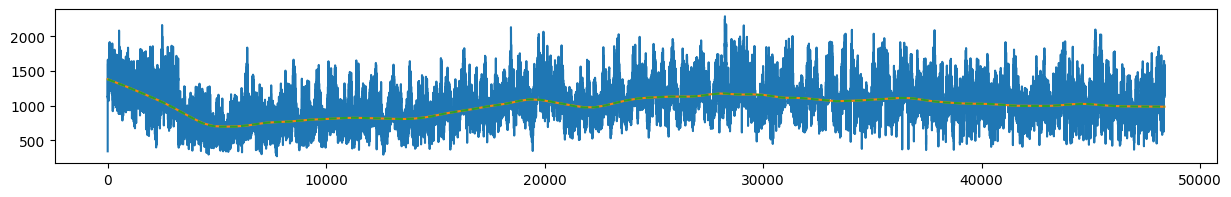

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(15,2))
ax.plot(trace)
ax.plot(fluct_sm)
ax.plot(fluct_sk, ls="--");

In [15]:
fluct_sm, fluct_sk = compare_lowess(trace, timestamps, weights=1e30/trace**10, frac=0.1)

statsmodels : 11.9 ms
skmisc      : 23.0 ms
speedup     : 1.9x  (statsmodels faster = >1)
max |Δ|     : 2.70e+01
max rel |Δ| : 6.14e-02
mean rel |Δ|: 3.85e-03


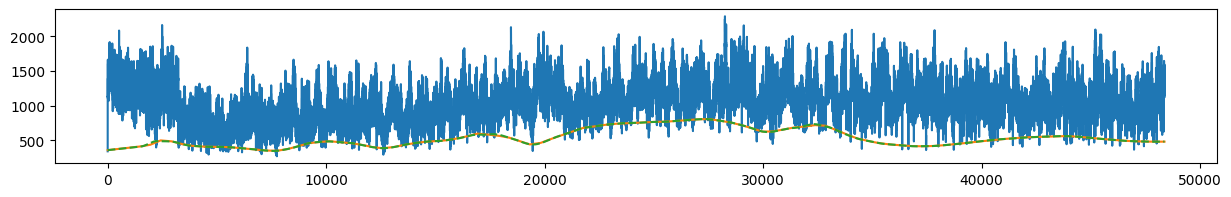

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(15,2))
ax.plot(trace)
ax.plot(fluct_sm)
ax.plot(fluct_sk, ls="--");

In [17]:
def double_exp_lin(params: np.ndarray, t: np.ndarray) -> np.ndarray:
    """
    Baseline with biphasic exponential decay (bleaching).

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, t_slow, t_fast, b_lin]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray
        Model prediction
    """
    b_inf, b_slow, b_fast, t_slow, t_fast, b_lin = params
    E_slow = np.exp(-t / t_slow)
    E_fast = np.exp(-t / t_fast)
    A = 1 + b_slow * E_slow + b_fast * E_fast + b_lin * t
    y = b_inf * A
    return y

In [18]:
def double_exp_lin_jax(params, t):
    b_inf, b_slow, b_fast, t_slow, t_fast, b_lin = params
    E_slow = jnp.exp(-t / t_slow)
    E_fast = jnp.exp(-t / t_fast)
    A = 1 + b_slow * E_slow + b_fast * E_fast + b_lin * t / t.max()
    y = b_inf * A
    return y

In [19]:
def double_exp_bright(
    params: np.ndarray, t: np.ndarray, return_jac: bool = False
) -> np.ndarray | tuple[np.ndarray, np.ndarray]:
    """
    Bright baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps
    return_jac : bool, optional
        If True, return Jacobian alongside the model prediction

    Returns
    -------
    y : np.ndarray
        Model prediction
    J : np.ndarray, optional
        Jacobian with respect to parameters (returned if return_jac=True)
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    # exponentials
    E_slow = np.exp(-t / t_slow)
    E_fast = np.exp(-t / t_fast)
    E_bright = np.exp(-t / t_bright)
    # helper terms
    A = 1 + b_slow * E_slow + b_fast * E_fast
    B = 1 - b_bright * E_bright

    y = b_inf * A * B
    if not return_jac:
        return y

    # precompute repeated products
    bE_B_slow = b_inf * E_slow * B
    bE_B_fast = b_inf * E_fast * B
    A_Eb = A * E_bright
    b_inf_A_Eb = b_inf * A_Eb
    # initialize Jacobian
    J = np.empty((t.size, 9))
    # amplitudes
    J[:, 0] = A * B  # d/d b_inf
    J[:, 1] = bE_B_slow  # d/d b_slow
    J[:, 2] = bE_B_fast  # d/d b_fast
    J[:, 3] = -b_inf_A_Eb  # d/d b_bright
    # time constants
    J[:, 4] = b_slow / t_slow**2 * bE_B_slow * t  # d/d t_slow
    J[:, 5] = b_fast / t_fast**2 * bE_B_fast * t  # d/d t_fast
    J[:, 6] = -b_bright / t_bright**2 * b_inf_A_Eb * t  # d/d t_bright

    return y, J

In [20]:
def double_exp_bright_jax(params, t):
    """
    Bright baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    # exponentials
    E_slow = jnp.exp(-t / t_slow)
    E_fast = jnp.exp(-t / t_fast)
    E_bright = jnp.exp(-t / t_bright)
    # helper terms
    A = 1 + b_slow * E_slow + b_fast * E_fast
    B = 1 - b_bright * E_bright

    y = b_inf * A * B
    return y

In [21]:
double_exp_lin_init = [trace[-1000:].mean(), 0.35, 0.2, 3600, 240, 0]
double_exp_bright_init = [trace[-1000:].mean(), 0.35, 0.2, 0.99, 3600, 240, 1e5]

double_exp_lin_bounds = [(0, np.inf)] * 3 + [(300, np.inf), (1, 1200), [-1, 1]]
double_exp_bright_bounds = [(0, np.inf)] * 4 + [(300, np.inf), (1, 1200), (1, np.inf)]

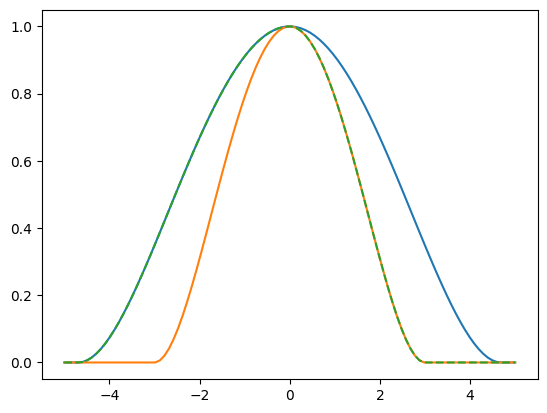

In [22]:
plt.plot(np.linspace(-5,5,100), TukeyBiweight().weights(np.linspace(-5,5,100)))
plt.plot(np.linspace(-5,5,100), TukeyBiweight(3).weights(np.linspace(-5,5,100)))
plt.plot(np.linspace(-5,5,100), AsymmetricTukeyBiweight(3, 4.685).weights(np.linspace(-5,5,100)), ls="--");

In [23]:
%%time
F0trend, res = nonlinear_fit(trace, timestamps, double_exp_bright, double_exp_bright_init, bounds=double_exp_bright_bounds,
                             M=AsymmetricTukeyBiweight(3, 4.685),
                             optimizer="L-BFGS-B",
                             optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10),
                             backend="numpy")

CPU times: user 10.5 s, sys: 9.79 ms, total: 10.5 s
Wall time: 5.3 s


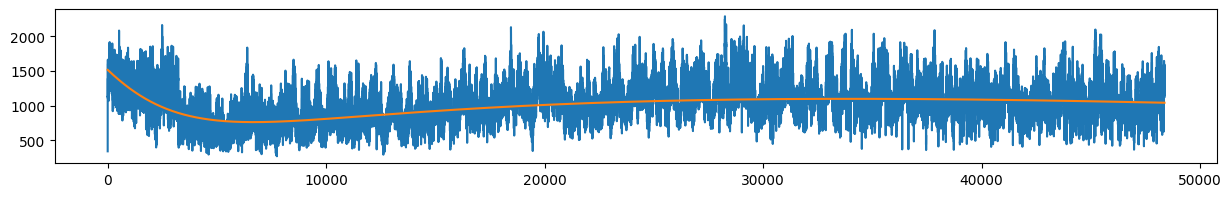

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(15,2))
ax.plot(trace)
ax.plot(F0trend)

In [25]:
%%time
F0trend, res = nonlinear_fit(trace, timestamps, double_exp_bright_jax, double_exp_bright_init, bounds=double_exp_bright_bounds,
                             M=AsymmetricTukeyBiweight_jax(3, 4.685),
                             optimizer="L-BFGS-B",
                             optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10),
                             backend="jax")

CPU times: user 5 s, sys: 191 ms, total: 5.19 s
Wall time: 2.95 s


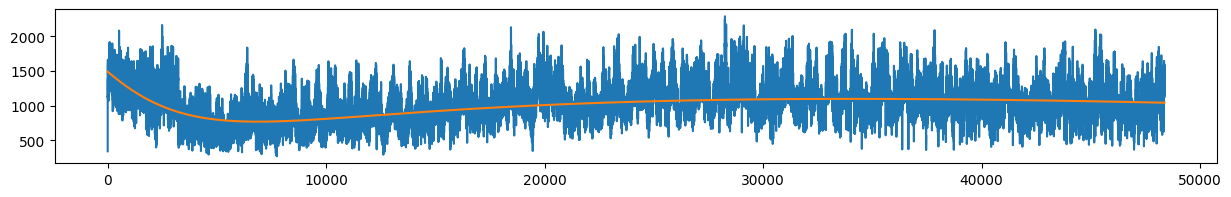

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(15,2))
ax.plot(trace)
ax.plot(F0trend)

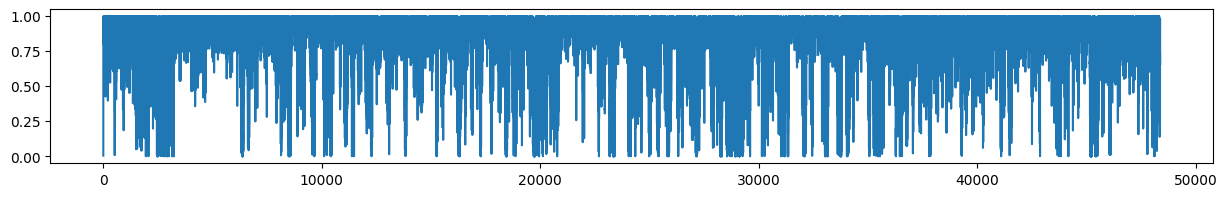

In [27]:
plt.figure(figsize=(15,2))
plt.plot(res.weights)

In [28]:
F0, F0fluct = fit_baseline_fluctuations_sm(trace, timestamps, F0trend, frac=.1, weights=res.weights)

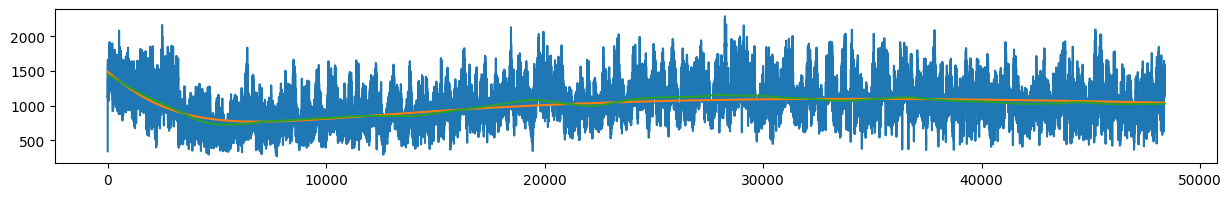

In [29]:
plt.figure(figsize=(15,2))
plt.plot(trace)
plt.plot(F0trend)
plt.plot(F0)

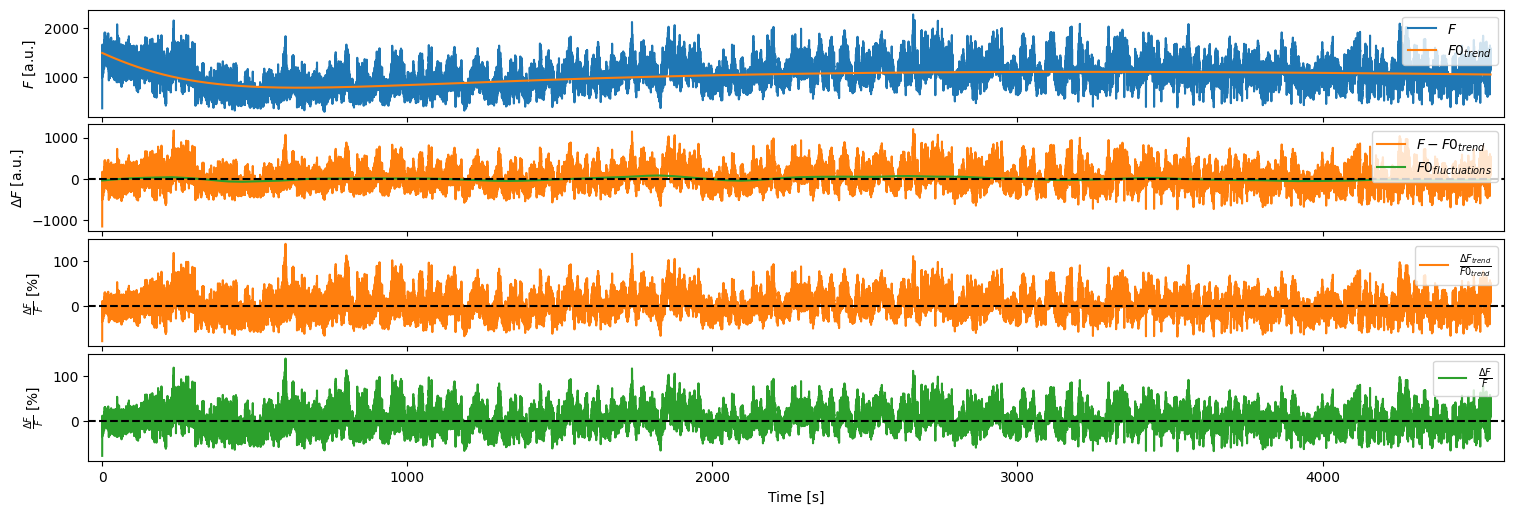

In [30]:
fix,ax=plt.subplots(4,1,figsize=(15,5), sharex=True)
ax[0].plot(timestamps, trace, label="$F$")
ax[0].plot(timestamps, F0trend, label="$F0_{trend}$")
ax[0].set_ylabel("$F$ [a.u.]")
ax[1].plot(timestamps, trace-F0trend, c="C1", label="$F-F0_{trend}$")
ax[1].plot(timestamps, F0-F0trend, c="C2", label="$F0_{fluctuations}$")
ax[1].axhline(0, ls="--", c="k")
ax[1].set_ylabel("$\\Delta F$ [a.u.]")
ax[2].plot(timestamps, 100 * (trace/F0trend-1), c="C1", label="$\\frac{\\Delta F_{trend}}{F0_{trend}}$")
ax[2].axhline(0, ls="--", c="k")
ax[2].set_ylabel("$\\frac{\\Delta F}{F}$ [%]")
ax[3].plot(timestamps, 100 * (trace/F0trend-1), c="C2", label="$\\frac{\\Delta F}{F}$")
ax[3].axhline(0, ls="--", c="k")
ax[3].set_ylabel("$\\frac{\\Delta F}{F}$ [%]")
for a in ax:
    a.legend(loc=1)
a.set_xlim(-.01*timestamps[-1], 1.01*timestamps[-1])
a.set_xlabel("Time [s]")
plt.tight_layout(pad=.2)

In [ ]:
def _fit_fluctuations_lowess(
    trace: np.ndarray,
    t: np.ndarray,
    trend: np.ndarray | None = None,
    frac: float = 0.1,
    weights: np.ndarray | None = None,
    mode: str = "ratio",
    M=None,
    maxiter: int = 5,
    tol: float = 1e-3,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit baseline fluctuations using LOWESS with optional robust IRLS.

    Parameters
    ----------
    trace : np.ndarray
        Raw signal.
    t : np.ndarray
        Timestamps (must be sorted).
    trend : np.ndarray or None
        Slow trend (e.g. from nonlinear_fit). If None, fits trace directly.
    frac : float
        LOWESS bandwidth as fraction of data length.
    weights : np.ndarray or None
        Initial point weights, e.g. res.weights from trend fit.
        Warm-starts the IRLS loop. Defaults to uniform weights.
    mode : {"ratio", "diff"}
        How to remove trend: "ratio" divides, "diff" subtracts.
    M : M-estimator or None
        If None, single-pass LOWESS. Otherwise, outer IRLS using M.weights.
        Any M-estimator with a .weights(z) method works, including
        AsymmetricTukeyBiweight and OneSidedTukeyBiweight.
    maxiter : int
        Maximum IRLS iterations. Ignored when M is None.
    tol : float
        Convergence tolerance on max weight change between iterations.

    Returns
    -------
    baseline : np.ndarray
        Full baseline (trend * fluctuation or trend + fluctuation).
    fluctuation : np.ndarray
        Fitted fluctuation component (ratio or residual relative to trend).
    """
    if trend is None:
        y = trace.astype(np.float64)
    elif mode == "ratio":
        y = (trace / np.where(trend != 0, trend, np.nan)).astype(np.float64)
    else:
        y = (trace - trend).astype(np.float64)

    t64 = t.astype(np.float64)
    w_current = (
        np.asarray(weights, dtype=np.float64)
        if weights is not None
        else np.ones(len(y), dtype=np.float64)
    )
    delta = 0.01 * (t64[-1] - t64[0])

    for _ in range(maxiter if M is not None else 1):
        fluctuation = _sm_lowess(
            y, t64, t64,
            resid_weights=w_current,
            frac=frac,
            it=0,
            delta=delta,
            is_sorted=True,
        )[0][:, 1]

        if M is None:
            break

        resid = y - fluctuation
        sigma = np.median(np.abs(resid)) * 1.4826
        if sigma == 0:
            sigma = np.std(resid)

        w_new = M.weights(resid / sigma)
        if np.max(np.abs(w_new - w_current)) < tol:
            break
        w_current = w_new

    if trend is None:
        return fluctuation, fluctuation
    baseline = trend * fluctuation if mode == "ratio" else trend + fluctuation
    return baseline, fluctuation

In [ ]:
def fit_baseline_fluctuations(
    trace, t,
    trend=None,
    mode="ratio",
    frac=0.1,
    weights=None,
    method="lowess",
    # lowess-specific
    M=None,
    maxiter=5,
    tol=1e-3,
    # percentile-specific
    percentile=None,   # None = estimate from weights
):
    if method == "lowess":
        return _fit_fluctuations_lowess(trace, t, trend, frac=frac, weights=weights, M=M, ...)
    elif method == "percentile":
        window = max(1, round(frac * len(trace)))
        if percentile is None:
            # estimate from weights if available
            y = trace / trend if ... else trace
            mu_w = np.average(y, weights=weights) if weights is not None else np.median(y)
            percentile = np.clip(np.mean(y <= mu_w) * 100, 5, 50)
        return _fit_fluctuations_percentile(trace, t, trend, window=window, percentile=percentile, ...)

In [ ]:
# LOWESS with robust IRLS
fit_baseline_fluctuations(trace, t, trend=trend, weights=res.weights,
                          method="lowess", params={"M": OneSidedTukeyBiweight()})

# percentile with auto-estimated q
fit_baseline_fluctuations(trace, t, trend=trend, weights=res.weights,
                          method="percentile")

# percentile with explicit override
fit_baseline_fluctuations(trace, t, trend=trend,
                          method="percentile", params={"percentile": 20})

In [4]:
percentile_filter??

Signature:
percentile_filter(
    input: numpy.ndarray,
    percentile: float,
    size: int,
    dtype: Optional[type] = None,
) -> numpy.ndarray
Source:   
def percentile_filter(
    input: np.ndarray,
    percentile: float,
    size: int,
    dtype: Optional[type] = None,
) -> np.ndarray:
    """
    Fast 1D running percentile filter using reflection
    to extend the input array beyond its boundaries.
    Uses pandas if input and filter size are long, scipy if short.

    Parameters
    ----------
    input: ndarray
        The input array.
    percentile : float
        The percentile parameter. Must be between 0 and 100 inclusive.
    size: int
        Length of the median filter to compute a rolling baseline.
    dtype: Optional[type]
        The dtype of the returned array. By default an array of
        the same dtype as input will be created.

    Returns
    -------
    filtered_trace: ndarray
        Filtered array. Has the same shape as `input`.
    """
    if dtype is Non